In [6]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41351 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41351/status,
Dashboard: http://127.0.0.1:41351/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33687,Workers: 56
Dashboard: http://127.0.0.1:41351/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:34359,Total threads: 1
Dashboard: http://127.0.0.1:38149/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:37749,


In [3]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [4]:
xr.set_options(keep_attrs=True)
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
plt.rcParams.update({"font.size": 22})

# Functions

In [45]:
def anomalize_func(ds):
    time_var = "time"
    climatology = (
        ds.sel(time=slice("2022-01", "2022-12"))
        .groupby(time_var + ".month")
        .mean(time_var)
    )
    anomalies = ds.copy()
    for sel_var in list(ds.data_vars)[:]:
        if sel_var in ["O3_m", "H2O_m"]:
            anomalies[sel_var] = (
                (ds[sel_var] - climatology[sel_var]) / climatology[sel_var] * 100
            )
            anomalies[sel_var].attrs["units"] = "%"
        else:
            anomalies[sel_var] = ds[sel_var] - climatology[sel_var]
            anomalies[sel_var].attrs["units"] = ds[sel_var].attrs["units"]
    return anomalies

def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))


def process_chem(ds, deseasonalize=True, upper_limit=0.1, lower_limit=300):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))


def process(ds, deseasonalize=True, upper_limit=0.01, lower_limit=200):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="ME", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))

def plot_diff(diff, ax):
    #cbar_kwargs = dict(fontsize = 12)
    p = diff.plot.contourf(
        yincrease = False, robust = True, 
        x = 'time', ax = ax, 
        levels = 21, cmap="RdYlGn_r",
        extend = 'both',
        #cbar_kwargs = cbar_kwargs
    )
    cbar = p.colorbar
    cbar.ax.tick_params(labelsize=10)
    label =  f"{diff.attrs['long_name']} [{diff.attrs['units']}]"
    cbar.set_label(label = label, size = 12)

def plot_o3(diff, ax, levels = [0.3]):
    CS = diff.plot.contour(ax = ax, yincrease = False, x = 'time', colors = 'k', levels = levels)
    ax.clabel(CS)

def plot_pv(diff_pv,ax):
    kwargs = dict(
        yincrease= False,
        # colors=("k"),
        add_colorbar=False,
        levels=[0, 0.05],
        colors="none",
        hatches=[
            "//",
            None,
        ],
        ax=ax,
        # linewidths=np.linspace(1, 4, 4),
    )

    diff_pv.squeeze().plot.contourf(x="time", **kwargs)
    kwargs['levels'] = [0,0.1]
    kwargs['hatches'] = ["\\",  None]
    diff_pv.squeeze().plot.contourf(x="time", **kwargs)

first_long_name = lambda x: x.split(' ')[0]

def get_diff(ds_w, ds_wo, sel_var, sel_dict, factor):
    arr1 = ds_w[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
    arr2 = ds_wo[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
    diff = arr1.mean('ens')-arr2.mean('ens')
    diff.attrs['long_name'] = first_long_name(diff.attrs['long_name'])
    diff.attrs['units'] = r'$10^{-9}$' + diff.attrs['units']

    t_stat, p_values = stats.ttest_ind(
        arr1, arr2, equal_var=False
    )  # , nan_policy = nan_policy)
    diff_pv = xr.DataArray(p_values, coords=diff.coords)
    
    return diff, diff_pv


In [ ]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1 = ds_w_wv['H2O_m'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()*1e6
arr2 = ds_wo_wv['H2O_m'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()*1e6
#diff = arr1 - arr2
diff_sel_pcap = arr1.mean('ens') - arr2.mean('ens')
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=diff_sel_pcap.coords)

## NOx

In [14]:
what = "NOx_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_NOx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_NOx_mm_zon_2021-2025.nc')]

In [15]:
ds_w_nox = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_w_nox = ds_w_nox.assign(NOx=lambda x: x.NO_m + x.NO2_m)
ds_w_nox['NOx'].attrs['long_name'] = 'NOx'
ds_w_nox

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg

<xarray.Dataset> Size: 39MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    NO_m     (ens, time, plev, lat, lon) float32 6MB 1.162e-10 ... 2.156e-10
    NO2_m    (ens, time, plev, lat, lon) float32 6MB 1.805e-10 ... 3.382e-11
    HNO3_m   (ens, time, plev, lat, lon) float32 6MB 2.108e-14 ... 2.838e-10
    NO3_m    (ens, time, plev, lat, lon) float32 6MB 8.865e-14 ... 3.171e-15
    N2O5_m   (ens, time, plev, lat, lon) float32 6MB 1.008e-15 ... 1.005e-14
    N2O_m    (ens, time, plev, lat, lon) float32 6MB 3.851e-10 ... 3.261e-07
    NOx      (ens, time, plev, lat, lon) float32 6MB 2.967e-10 ... 2.494e-10
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 15:51:11 2024: cdo cat Postproc_example-NOx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [16]:
ds_wo_nox = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_wo_nox = ds_wo_nox.assign(NOx=lambda x: x.NO_m + x.NO2_m)
ds_wo_nox['NOx'].attrs['long_name'] = 'NOx'
ds_wo_nox

<xarray.Dataset> Size: 39MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    NO_m     (ens, time, plev, lat, lon) float32 6MB nan nan ... 2.223e-10
    NO2_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 6.308e-11
    HNO3_m   (ens, time, plev, lat, lon) float32 6MB nan nan ... 6.851e-10
    NO3_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 6.636e-15
    N2O5_m   (ens, time, plev, lat, lon) float32 6MB nan nan ... 3.86e-14
    N2O_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 3.12e-07
    NOx      (ens, time, plev, lat, lon) float32 6MB nan nan ... 2.854e-10
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 15:51:41 2024: cdo cat Postproc_example-NOx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [24]:
weights = np.cos(np.deg2rad(ds_w_nox.lat))
weights.name = "weights"

In [15]:
sel_var = ["NO_m", 'NO2_m']
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_nox[sel_var].sel(**sel_dict).to_array().sum('variable').weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_nox[sel_var].sel(**sel_dict).to_array().sum('variable').weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')

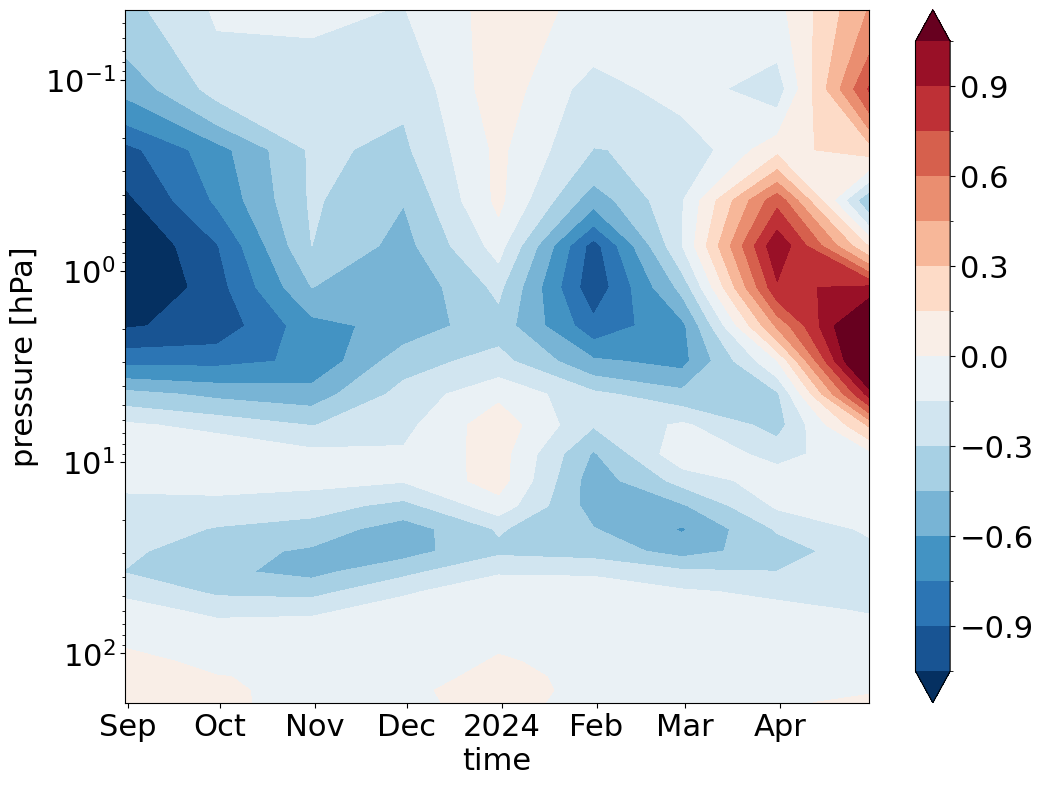

In [16]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

In [17]:
sel_var = "HNO3_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')

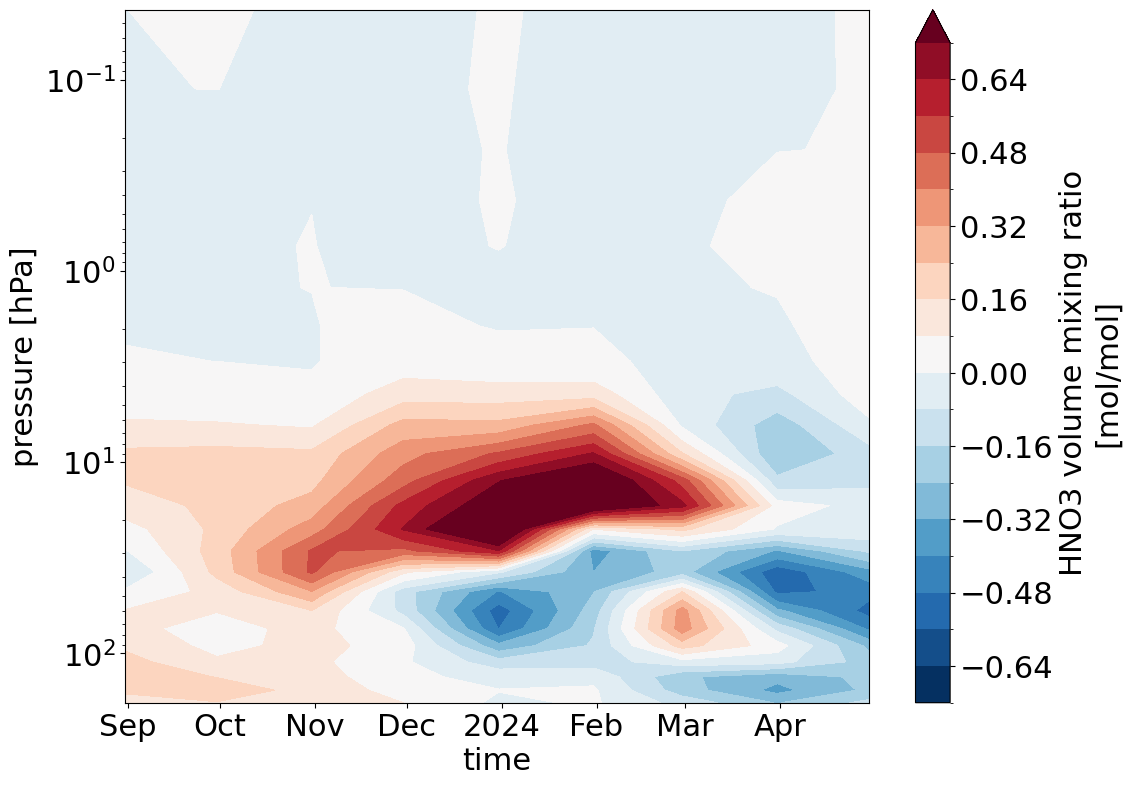

In [18]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

In [19]:
sel_var = "N2O5_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')

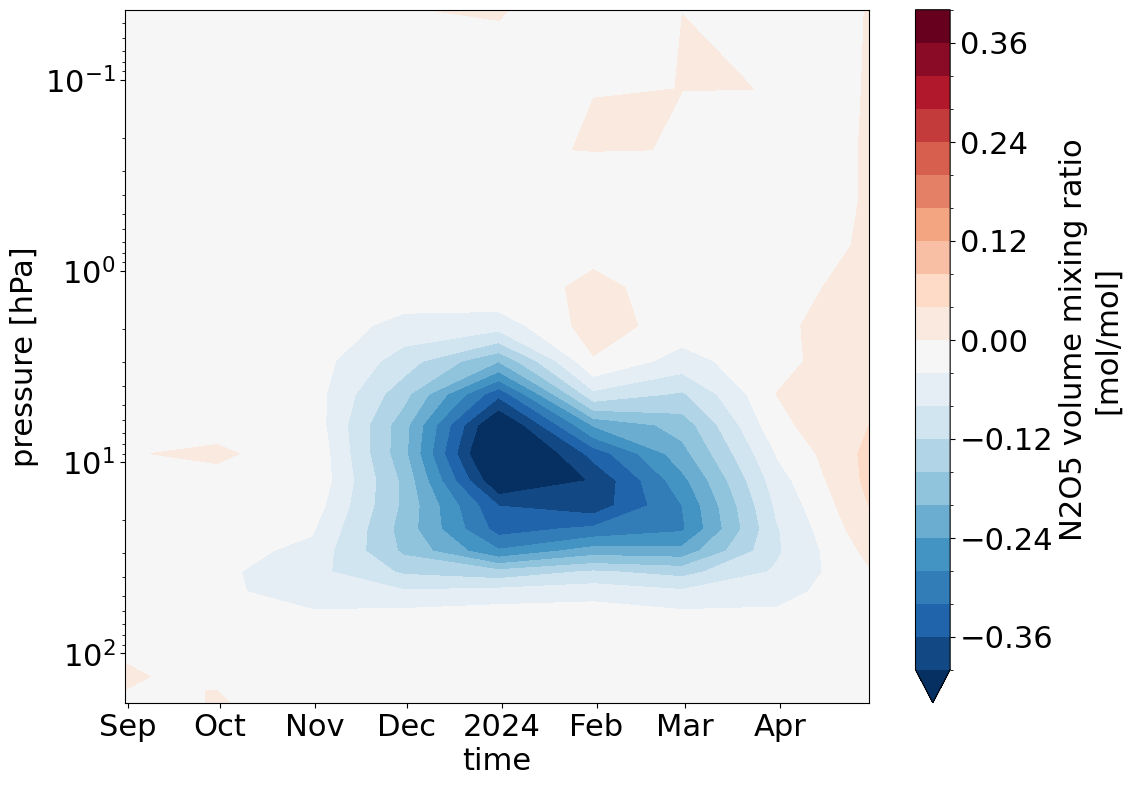

In [20]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

In [21]:
sel_var = "N2O_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_nox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')

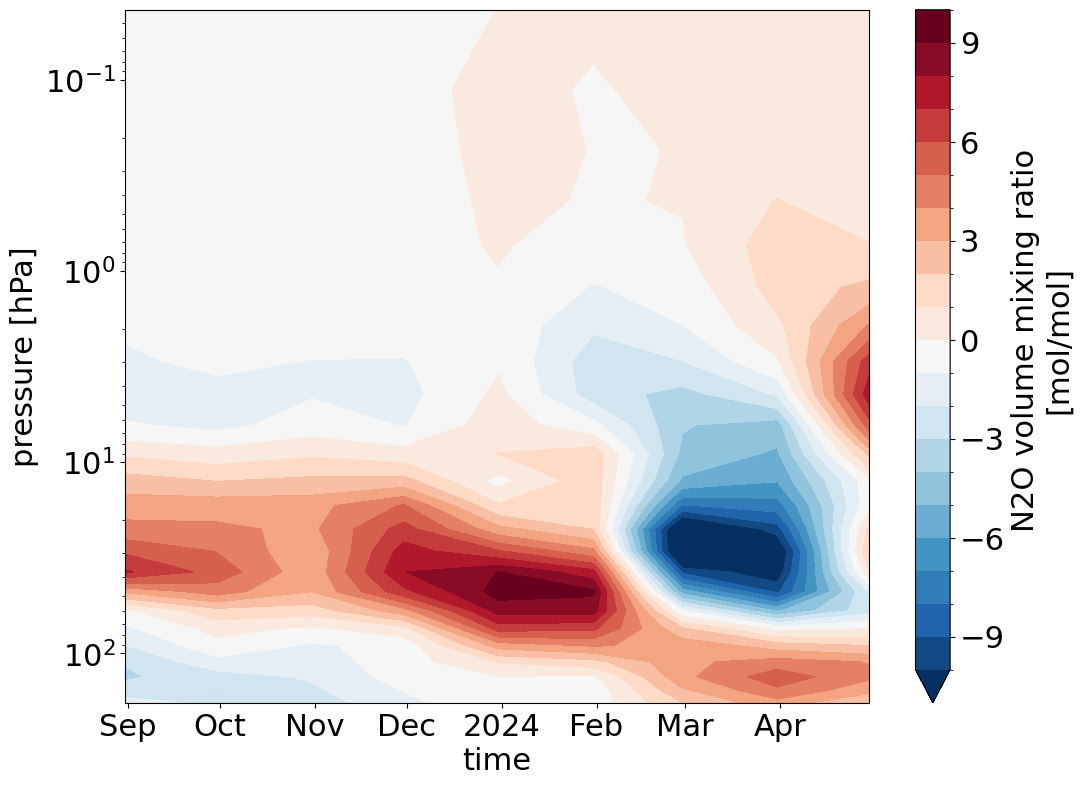

In [22]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

## HOx

In [17]:
what = "OHx_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_OHx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_OHx_mm_zon_2021-2025.nc')]

In [18]:
ds_w_hox = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_w_hox

<xarray.Dataset> Size: 6MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    OH_m     (ens, time, plev, lat, lon) float32 6MB 6.741e-12 ... 4.696e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 14:28:51 2024: cdo cat Postproc_example-OHx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [19]:
ds_wo_hox = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_wo_hox

<xarray.Dataset> Size: 6MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    OH_m     (ens, time, plev, lat, lon) float32 6MB nan nan ... 4.436e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 14:29:26 2024: cdo cat Postproc_example-OHx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [26]:
weights = np.cos(np.deg2rad(ds_w_nox.lat))
weights.name = "weights"

In [27]:
sel_var = "OH_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_hox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_hox[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')
diff

<xarray.DataArray 'OH_m' (time: 9, plev: 24)> Size: 2kB
array([[ 1.65358681e-01,  5.33513877e-02,  3.07033715e-02,
         2.57210123e-02,  2.16510657e-02,  1.85006243e-02,
         1.40014846e-02,  8.43750580e-03,  4.06916783e-03,
         2.03791291e-03,  1.02593024e-03,  4.58099046e-04,
         2.05789774e-04,  9.79681087e-05,  5.58146727e-05,
         3.59561634e-05,  1.82385642e-05,  9.82686889e-06,
         4.98159906e-06, -4.96693252e-07, -6.02438441e-06,
        -6.02274709e-06, -1.99903365e-06,  6.94944969e-07],
       [ 1.12965032e-01,  3.00065299e-02,  2.39061743e-02,
         1.95763202e-02,  1.64303269e-02,  1.38739661e-02,
         9.82766636e-03,  5.42500498e-03,  2.56442774e-03,
         1.32490597e-03,  6.94640444e-04,  3.24166647e-04,
         1.49795137e-04,  7.49330379e-05,  4.48644523e-05,
         2.98221380e-05,  2.05793793e-05,  1.37278502e-05,
         9.27189621e-06,  5.61863367e-06,  9.14398959e-07,
        -2.83988658e-06, -3.51739513e-06, -2.81966558e-06],
       [ 8.26711582e-03,  9.19570169e-03,  1.15488452e-02,
         1.10384174e-02,  8.36921440e-03,  6.73617186e-03,
         4.42364318e-03,  2.10053475e-03,  1.15616970e-03,
         7.18053563e-04,  3.86658649e-04,  1.69228225e-04,
...
         5.98152142e-07,  4.65043771e-06,  8.63064964e-06,
         7.02166358e-06,  5.33907168e-06,  3.72644557e-06,
         1.81682727e-06,  5.42201727e-07, -3.83774142e-07,
        -8.64808739e-07, -4.34555251e-07,  1.89174854e-06],
       [ 3.27179177e-02,  8.66131305e-03,  1.02453606e-02,
         1.02400899e-02,  9.39966948e-03,  5.74283900e-03,
         2.90209601e-03,  1.20517815e-03,  3.71288978e-04,
         1.77415642e-04,  1.60396613e-04,  1.08362187e-04,
         5.34972855e-05,  3.08297016e-05,  2.34118432e-05,
         2.08557668e-05,  1.89098846e-05,  1.61592472e-05,
         1.15901090e-05,  8.39178428e-06,  7.19941504e-06,
         7.26279409e-06,  6.80932848e-06,  5.44904524e-06],
       [-2.98321041e-02, -1.02516120e-02,  3.22162028e-04,
         6.24486030e-03,  8.25872763e-03,  7.16500676e-03,
         4.02886398e-03,  2.65905932e-03,  1.84856319e-03,
         9.18585696e-04,  3.92185143e-04,  1.89983414e-04,
         1.00384480e-04,  5.02779367e-05,  2.99836114e-05,
         2.36727003e-05,  1.85968310e-05,  1.57648509e-05,
         1.35749671e-05,  1.11512621e-05,  1.02672080e-05,
         1.04675005e-05,  9.84301113e-06,  6.95587553e-06]])
Coordinates:
  * time     (time) datetime64[ns] 72B 2023-08-31 2023-09-30 ... 2024-04-30
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Attributes:
    long_name:         OH volume mixing ratio
    units:             mol/mol
    code:              23
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

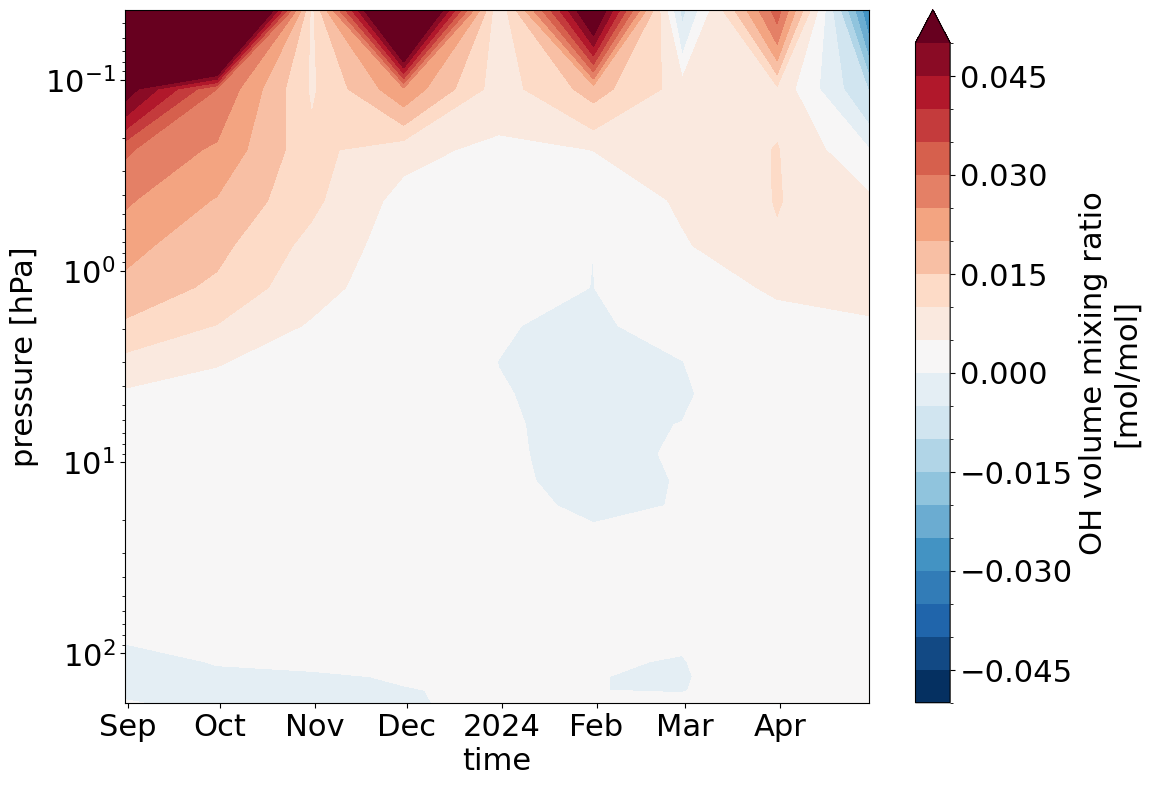

In [28]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

## Clx

In [20]:
what = "Clx_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_Clx_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_Clx_mm_zon_2021-2025.nc')]

In [21]:
ds_w_clx = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_w_clx = ds_w_clx.assign(ClOx=lambda x: x.Cl_m + x.ClO_m)
ds_w_clx

<xarray.Dataset> Size: 44MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    ClNO3_m  (ens, time, plev, lat, lon) float32 6MB 4.203e-15 ... 8.608e-12
    ClO_m    (ens, time, plev, lat, lon) float32 6MB 1.461e-10 ... 7.033e-13
    Cl_m     (ens, time, plev, lat, lon) float32 6MB 5.05e-14 ... 2.145e-15
    HOCl_m   (ens, time, plev, lat, lon) float32 6MB 6.814e-11 ... 1.908e-13
    HCl_m    (ens, time, plev, lat, lon) float32 6MB 2.837e-09 ... 2.629e-10
    Cl2_m    (ens, time, plev, lat, lon) float32 6MB 6.212e-14 ... 1.588e-14
    BrCl_m   (ens, time, plev, lat, lon) float32 6MB 7.814e-13 ... 1.148e-15
    ClOx     (ens, time, plev, lat, lon) float32 6MB 1.461e-10 ... 7.055e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 16:22:48 2024: cdo cat Postproc_example-Clx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [22]:
ds_wo_clx = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process, deseasonalize=False, upper_limit = 0.01)
    .load()
)
ds_wo_clx = ds_wo_clx.assign(ClOx=lambda x: x.Cl_m + x.ClO_m)
ds_wo_clx

<xarray.Dataset> Size: 44MB
Dimensions:  (ens: 10, time: 60, plev: 24, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Dimensions without coordinates: ens
Data variables:
    ClNO3_m  (ens, time, plev, lat, lon) float32 6MB nan nan ... 2.928e-12
    ClO_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 4.371e-13
    Cl_m     (ens, time, plev, lat, lon) float32 6MB nan nan ... 1.789e-15
    HOCl_m   (ens, time, plev, lat, lon) float32 6MB nan nan ... 8.982e-14
    HCl_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 1.396e-10
    Cl2_m    (ens, time, plev, lat, lon) float32 6MB nan nan ... 2.388e-14
    BrCl_m   (ens, time, plev, lat, lon) float32 6MB nan nan ... 1.417e-15
    ClOx     (ens, time, plev, lat, lon) float32 6MB nan nan ... 4.389e-13
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Fri Mar 22 16:23:25 2024: cdo cat Postproc_example-Clx-para...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [32]:
weights = np.cos(np.deg2rad(ds_w_nox.lat))
weights.name = "weights"

In [33]:
sel_var = "ClOx"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')
diff

<xarray.DataArray 'ClOx' (time: 9, plev: 24)> Size: 2kB
array([[ 1.34217243e-03,  2.79606553e-03,  6.28267771e-03,
         1.03477919e-02,  1.79435619e-02,  2.99428555e-02,
         3.67979941e-02,  3.31982260e-02,  2.37219661e-02,
         1.19979450e-02,  4.94111040e-03,  3.17445874e-03,
         2.44299493e-03,  1.67208605e-03,  1.58688241e-03,
         1.60027111e-03,  1.08060148e-03,  5.36691346e-04,
         2.77312273e-04,  1.42054086e-04,  1.59715651e-04,
         1.67875191e-04,  1.72109287e-04,  9.39034935e-05],
       [ 1.00625140e-03,  2.37914869e-03,  5.02212731e-03,
         8.70778763e-03,  1.55554978e-02,  2.60904065e-02,
         3.38851806e-02,  3.18128623e-02,  2.19790911e-02,
         1.11721785e-02,  3.79261943e-03,  1.77052425e-03,
         1.46658614e-03,  1.74642154e-03,  2.08342722e-03,
         2.12785915e-03,  2.01330872e-03,  1.40042489e-03,
         6.82819175e-04,  2.80567917e-04,  1.48448104e-04,
         1.75481580e-04,  2.04242720e-04,  1.44423519e-04],
       [ 1.94718833e-03,  7.50112087e-04,  3.10404192e-03,
         5.48592315e-03,  1.05441736e-02,  1.63999907e-02,
         2.14139912e-02,  2.25804804e-02,  1.48345849e-02,
         6.86815144e-03,  2.50177763e-03,  1.18769474e-03,
...
         1.18852430e-03,  1.14767006e-02,  4.23466679e-02,
         5.50416918e-02,  5.74174531e-02,  4.83928858e-02,
         3.64671761e-02,  2.34825656e-02,  1.75357122e-02,
         1.76925581e-02,  1.39065682e-02,  7.66600115e-03],
       [-3.38289936e-04, -2.87720582e-04, -9.47861331e-04,
        -1.57177671e-03, -5.14167149e-03, -1.21824689e-02,
        -1.15776703e-02,  1.76034713e-03,  8.05384872e-03,
         6.37719145e-03,  2.50268897e-03,  6.09914840e-04,
         9.50525778e-04,  3.50793080e-03,  1.90926547e-02,
         3.97924724e-02,  4.19467703e-02,  3.16540913e-02,
         2.33482912e-02,  1.70564625e-02,  1.30933436e-02,
         1.21329677e-02,  1.14588774e-02,  5.82911261e-03],
       [-7.96668737e-04, -5.02437199e-04,  1.70470361e-03,
         1.57735219e-03,  5.58921477e-04, -4.29763159e-03,
        -1.94259141e-02, -3.33466928e-02, -2.72266630e-02,
        -9.48731164e-03,  2.29398272e-03,  4.58810092e-03,
         3.04993997e-03,  2.19385926e-03,  2.25259266e-03,
         2.74004387e-03,  3.01605172e-03,  2.89139390e-03,
         2.33205795e-03,  1.98616477e-03,  2.85308770e-03,
         2.52240563e-03,  8.29104699e-05,  5.14672231e-04]])
Coordinates:
  * time     (time) datetime64[ns] 72B 2023-08-31 2023-09-30 ... 2024-04-30
  * plev     (plev) float64 192B 0.04281 0.1112 0.2315 ... 132.4 155.8 181.2
Attributes:
    long_name:         Cl volume mixing ratio
    units:             mol/mol
    code:              25
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

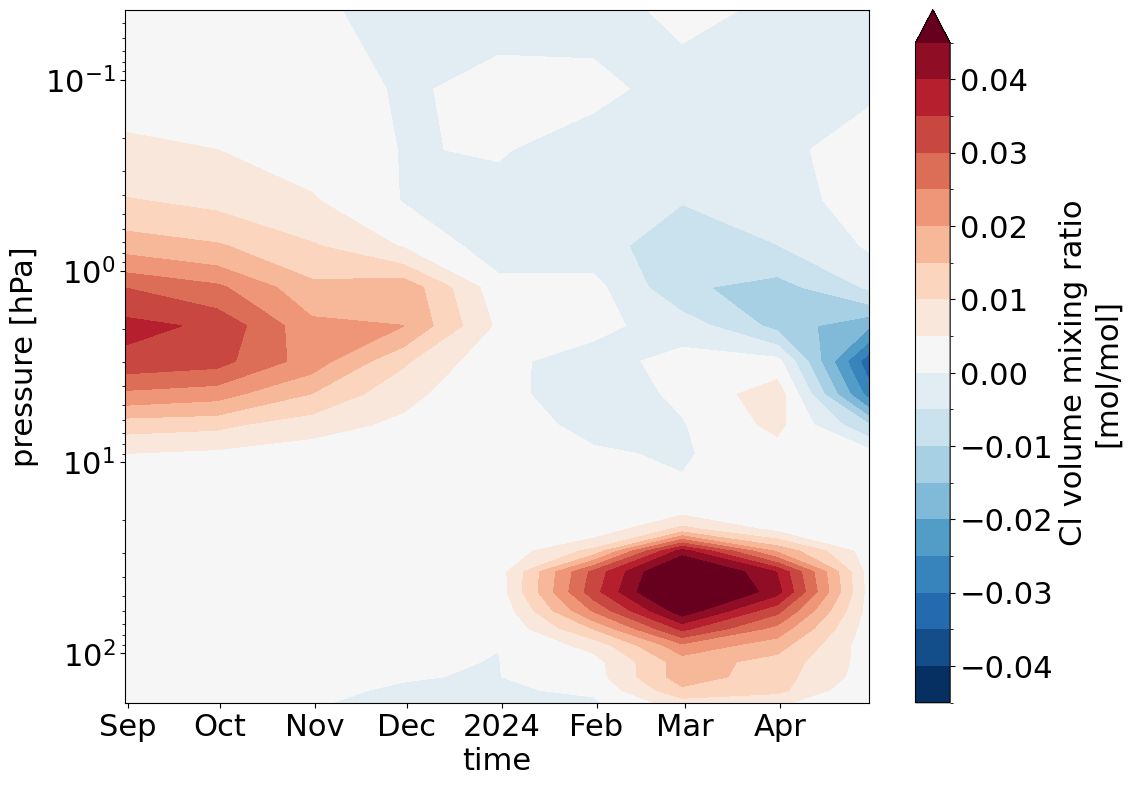

In [34]:
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

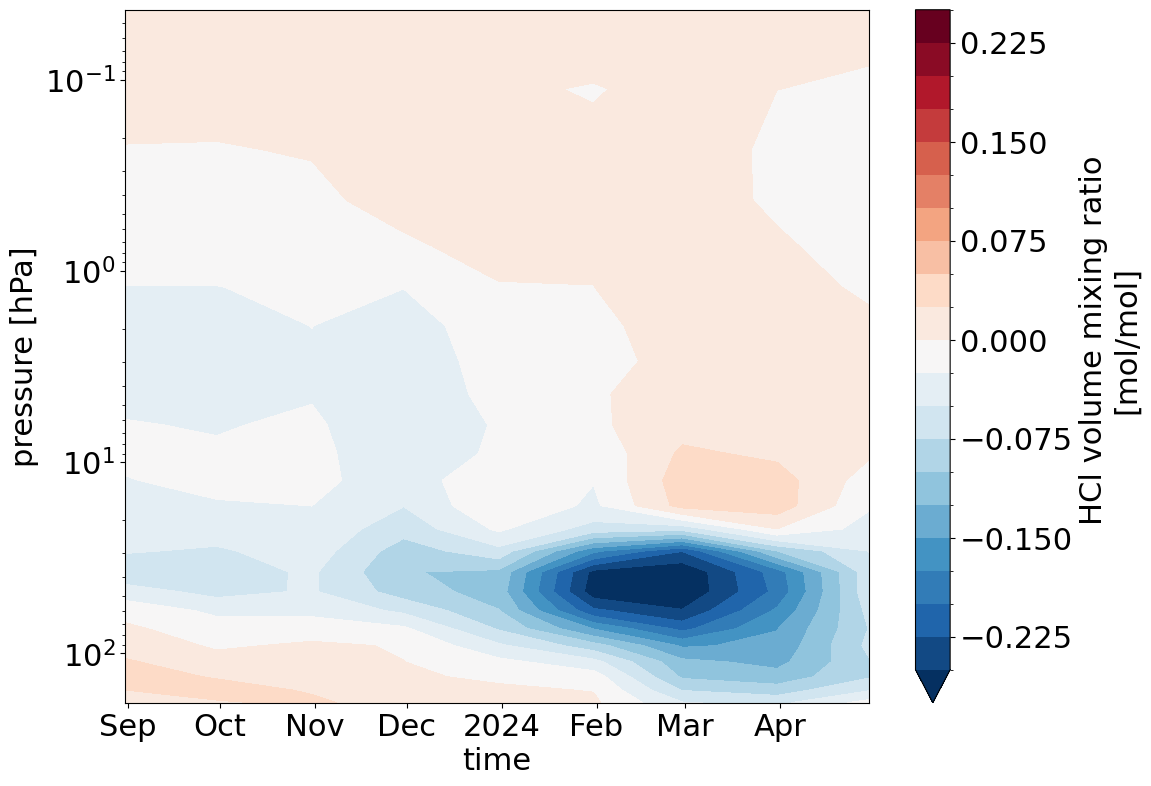

In [35]:
sel_var = "HCl_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

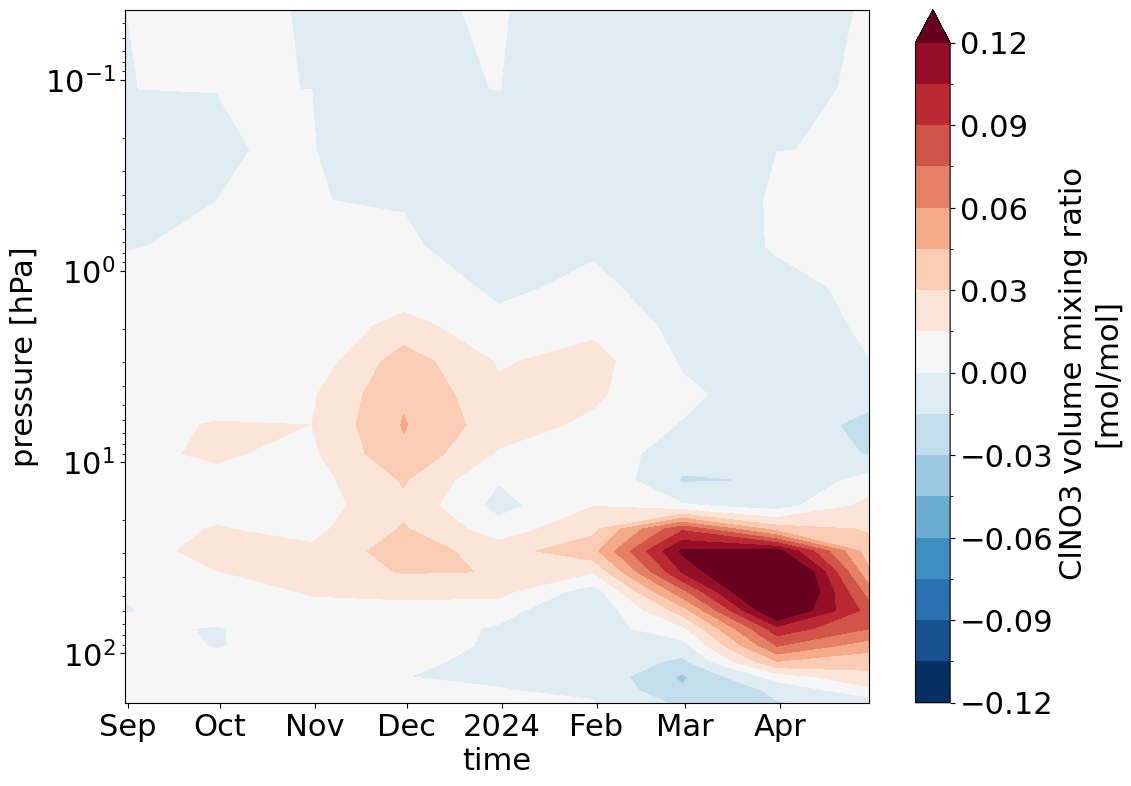

In [36]:
sel_var = "ClNO3_m"
time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

arr1 = ds_w_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
arr2 = ds_wo_clx[sel_var].sel(**sel_dict).weighted(weights).mean(['lat', 'lon'])*factor
diff = arr1.mean('ens')-arr2.mean('ens')
diff.plot.contourf(yincrease = False, robust = True, x = 'time', size = 9, levels = 21)
plt.yscale('log')

## ozone

In [8]:
what = "chem_mm_zon"
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*"))

In [9]:
infiles_wo

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt28_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt29_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt24_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt25_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt27_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt26_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt23_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt22_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt20_chem_mm_zon_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt21_chem_mm_zon_2021-2025.nc')]

In [12]:
ds_wo_chem = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_wo_chem

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 19MB
Dimensions:  (ens: 10, time: 60, plev: 21, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.04281 0.1112 0.2315 ... 74.06 91.02 110.7
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 5MB nan nan nan ... 206.3 206.4
    u_m      (ens, time, plev, lat, lon) float32 5MB nan nan nan ... 3.147 1.544
    O3_m     (ens, time, plev, lat, lon) float32 5MB nan nan ... 3.384e-07
    H2O_m    (ens, time, plev, lat, lon) float32 5MB nan nan ... 4.482e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Thu Feb 29 16:07:22 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [13]:
ds_w_chem = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_w_chem

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tmp/ipykernel_798486/3859801374.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__nam

<xarray.Dataset> Size: 19MB
Dimensions:  (ens: 10, time: 60, plev: 21, lat: 96, lon: 1)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.04281 0.1112 0.2315 ... 74.06 91.02 110.7
Dimensions without coordinates: ens
Data variables:
    te_m     (ens, time, plev, lat, lon) float32 5MB 236.8 236.3 ... 224.4 224.5
    u_m      (ens, time, plev, lat, lon) float32 5MB -1.594 -1.359 ... 0.02829
    O3_m     (ens, time, plev, lat, lon) float32 5MB 1.577e-06 ... 7.908e-07
    H2O_m    (ens, time, plev, lat, lon) float32 5MB 2.381e-06 ... 3.57e-06
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Mar 12 10:25:13 2024: cdo cat ss4.nc /scratch/snx3000/a...
    frequency:    mon
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

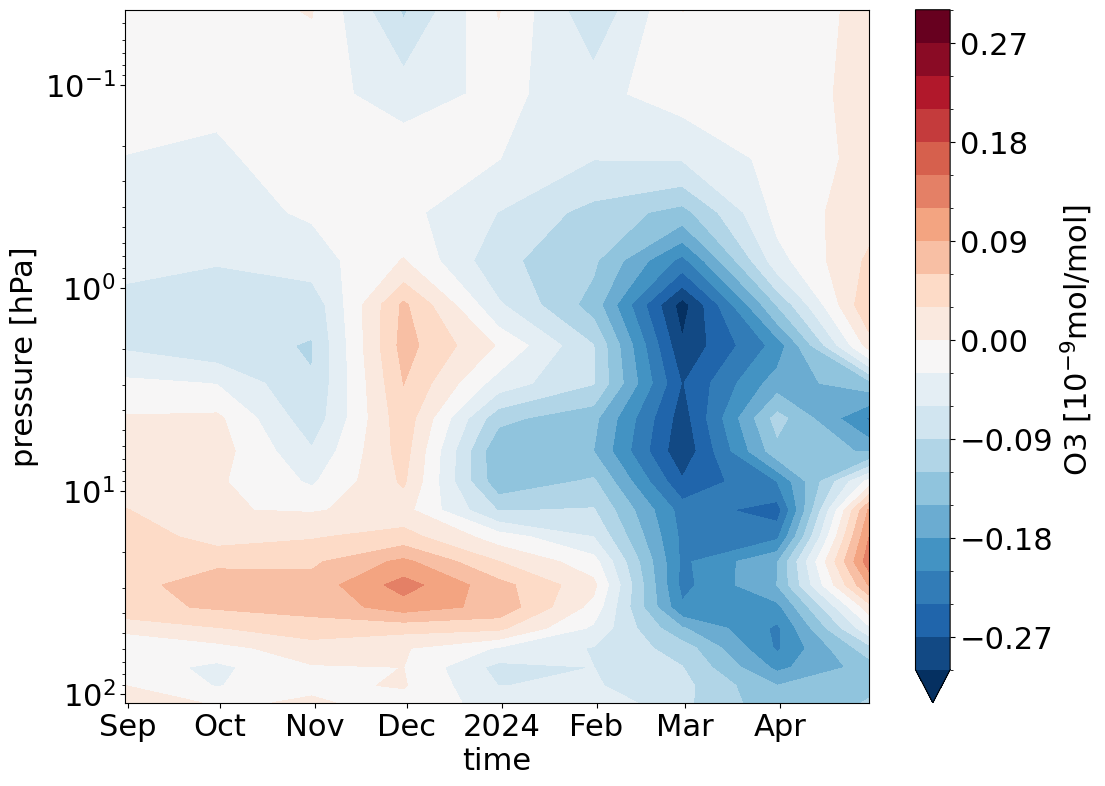

In [41]:
(diff_o3).plot.contourf(x = 'time', yincrease = False, robust = True, size = 9, levels = 21)
plt.yscale('log')

In [43]:
what = "ozone"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [46]:
ds_w_o3 = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:28 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [47]:
ds_wo_o3 = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lon      (lon) float64 8B 0.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:49 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [48]:
weights = np.cos(np.deg2rad(ds_w_o3.lat))
weights.name = "weights"

dims4ave = ['ens']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1_o3 =  ds_w_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()
arr2_o3 =  ds_wo_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()

In [62]:
diff_o3 = (arr1_o3.mean("ens")*1e6-arr2_o3.mean("ens")*1e6) 
#diff_o3 = ((arr1-arr2) ).mean("ens")
diff_o3.attrs['units'] = 'ppmv'
diff_o3.attrs['long_name'] = 'O3 VMR'

diff_o3_rel = ((arr1_o3.mean("ens")-arr2_o3.mean("ens")) / arr1_o3.mean("ens") * 100)
diff_o3_rel.attrs['units'] = '%'
diff_o3_rel.attrs['long_name'] = 'O3 VMR'

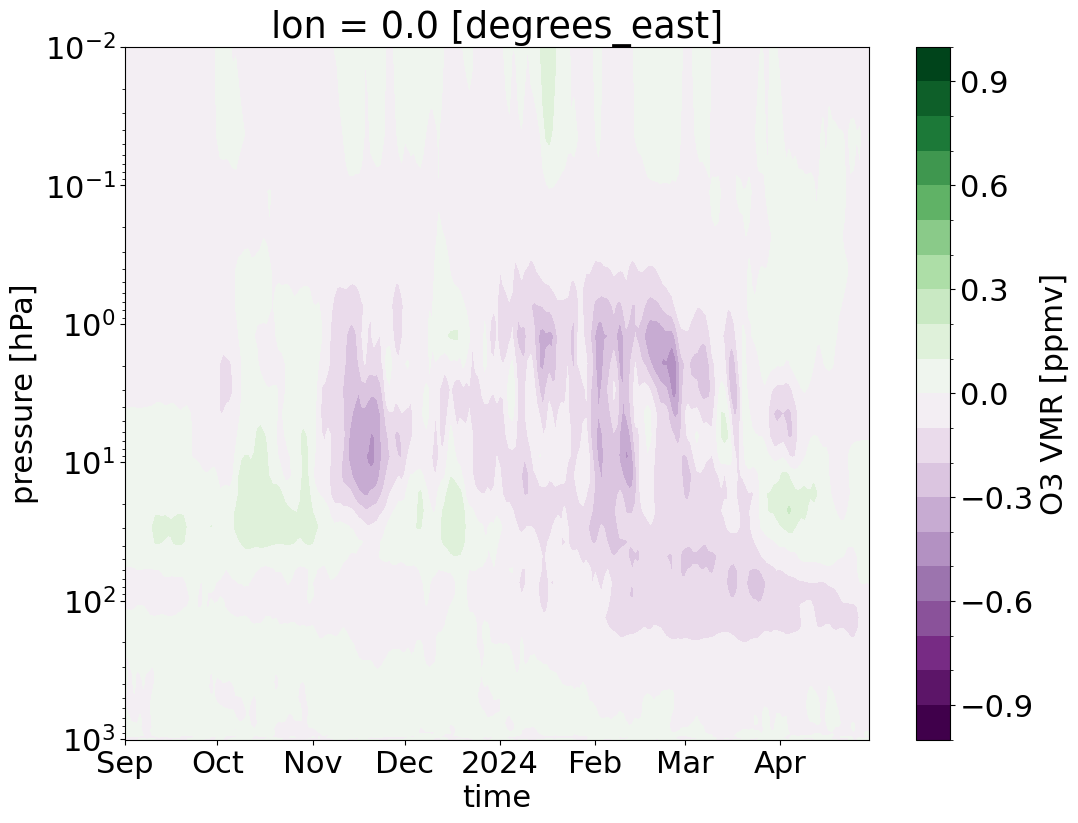

In [61]:
(diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, robust = True, 
    size = 9, levels = 21, vmax = 1, cmap = 'PRGn')
plt.yscale('log')

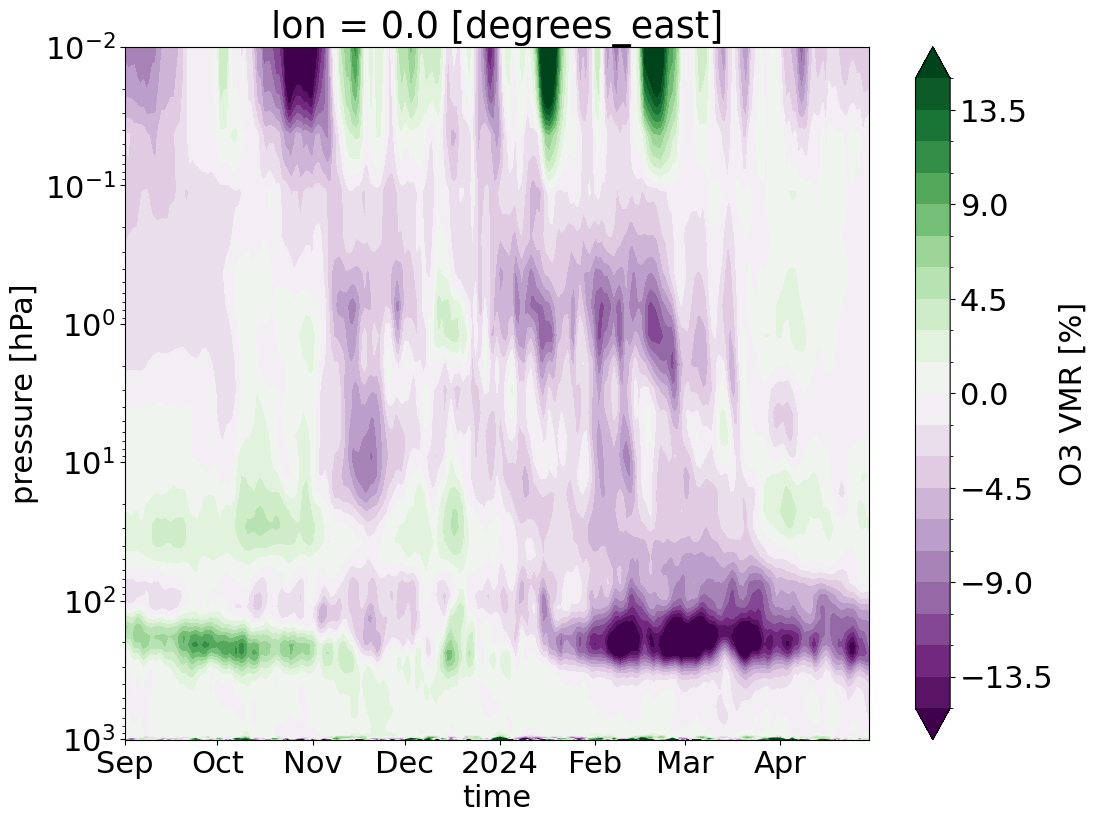

In [64]:
(diff_o3_rel.squeeze()).plot.contourf(
    x = 'time', yincrease = False, robust = True, 
    size = 9, levels = 21,  cmap = 'PRGn')
plt.yscale('log')

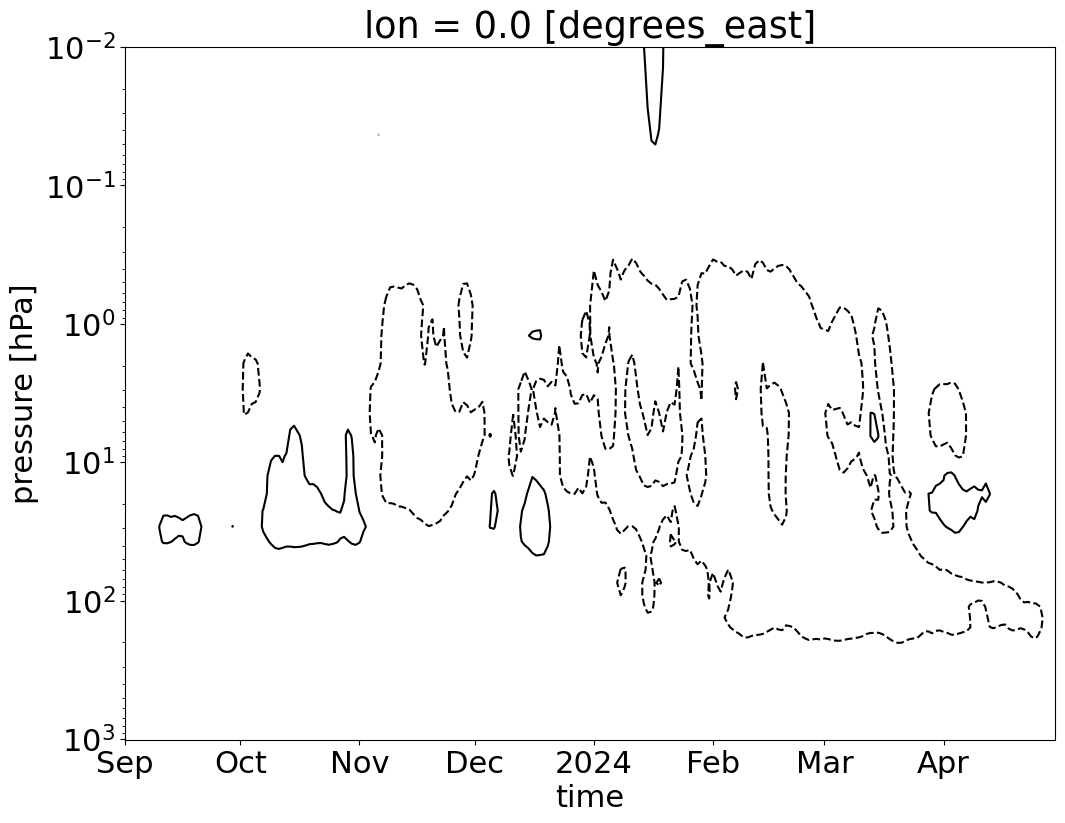

In [54]:
(diff_o3.squeeze()).plot.contour(x = 'time', yincrease = False, robust = True, size = 9, levels = [-0.1,0.1], colors = 'k')
plt.yscale('log')

## all

polar-chemistry_2023-2024.pdf


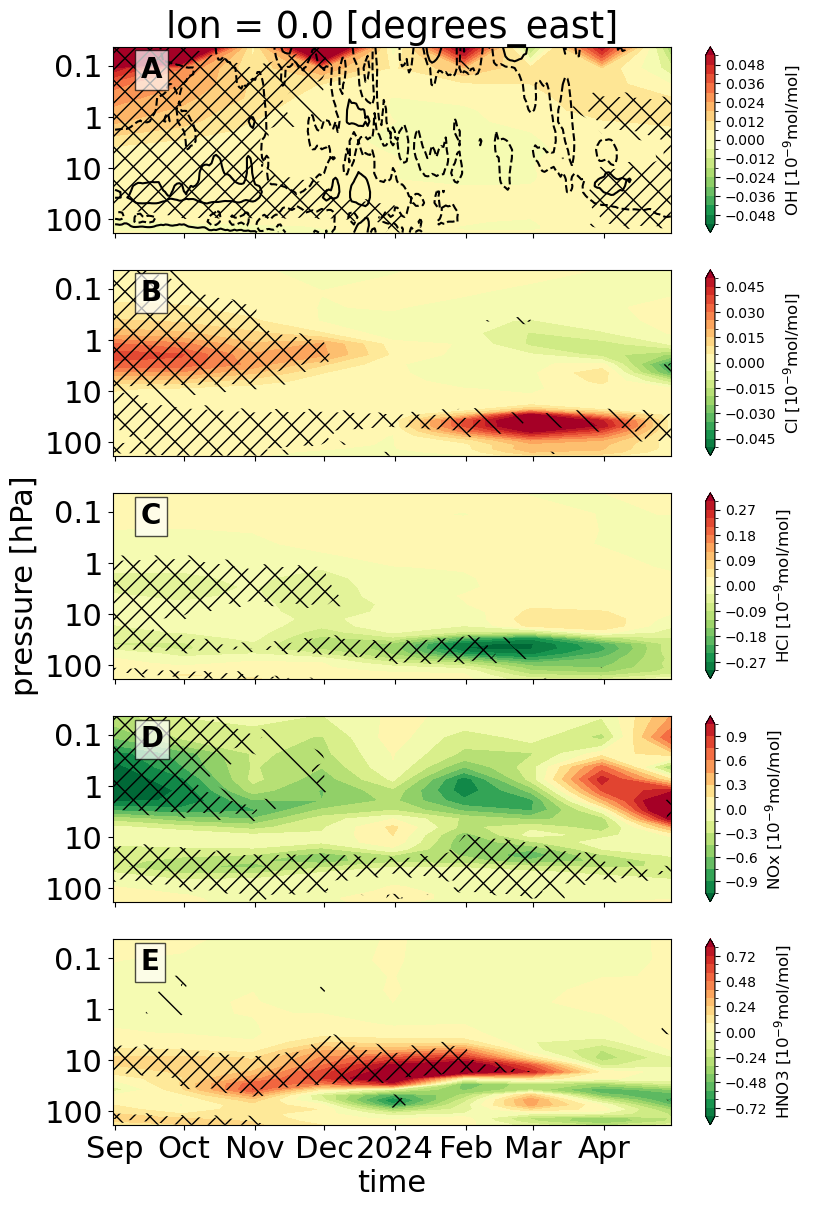

In [70]:
n_rows = 5
f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []


time_slice = slice("2023-08", "2024-04")
sel_dict = dict(time=time_slice, lat=slice(None, 60))
factor = 1e9

#diff_o3, _ = get_diff(ds_w_chem, ds_wo_chem, "O3_m", sel_dict, 1e6)
diff, diff_pv = get_diff(ds_w_hox, ds_wo_hox, "OH_m", sel_dict, factor)
ax = axes[0]
plot_diff(diff, ax)
plot_pv(diff_pv, ax)
levels = [-12,-3,-1,1,6,12]
levels = [-2,2]
#plot_o3(diff_o3, ax, levels)
diff_o3_rel.squeeze().sel(
    plev = slice(0.01,200)
).plot.contour(
    x = 'time', yincrease = False, 
    robust = True, ax=ax, 
    levels = levels, colors = 'k'
)

diff, diff_pv = get_diff(ds_w_clx, ds_wo_clx, 'ClOx', sel_dict, factor)
ax = axes[1]
plot_diff(diff, ax)
plot_pv(diff_pv, ax)

diff, diff_pv = get_diff(ds_w_clx, ds_wo_clx, 'HCl_m', sel_dict, factor)
ax = axes[2]
plot_diff(diff, ax)
plot_pv(diff_pv, ax)

diff, diff_pv = get_diff(ds_w_nox, ds_wo_nox, 'NOx', sel_dict, factor)
ax = axes[3]
plot_diff(diff, ax)
plot_pv(diff_pv, ax)

diff, diff_pv = get_diff(ds_w_nox, ds_wo_nox, 'HNO3_m', sel_dict, factor)
ax = axes[4]
plot_diff(diff, ax)
plot_pv(diff_pv, ax)

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 2:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')


outfile = f"polar-chemistry_2023-2024.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

In [50]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [52]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)